In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, chi2_contingency

# Data Preparation

### 1. Import the dataset and handle encoding/formatting issues.

In [2]:
# solving the encoding issue
df = pd.read_csv("DiwaliSalesData_264932.csv", encoding="latin1")
# import again after solving the issue 
df.to_csv("FormattedDiwaliSales.csv", encoding="utf-8", index=False)
df = pd.read_csv("FormattedDiwaliSales.csv")

In [3]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
df.info() # checking the information of dataset

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


# Data Cleaning

### 1. Convert Age Group to an ordinal categorical variable (e.g., Teen, Adult, Senior)

In [5]:
# converting age group to an ordinal categorical values.
age_groups = {
    '0-17'  : 'Teen',
    '18-25' : 'Young Adult',
    '26-35' : 'Adult',
    '36-45' : 'Adult',
    '46-50' : 'Middle-Aged',
    '51-55' : 'Middle-Aged',
    '55+'   : 'Senior'
}

df['Age Group'] = df['Age Group'].str.strip()  # remove spaces
df['Age Group'] = df['Age Group'].map(age_groups)
df['Age Group'] = pd.Categorical(df['Age Group'],categories=['Teen','Young Adult','Adult','Middle-Aged','Senior'],ordered=True)
print(df['Age Group'].unique())
df.iloc[1:5,[4,5]]

['Adult', 'Teen', 'Young Adult', 'Senior', 'Middle-Aged']
Categories (5, str): ['Teen' < 'Young Adult' < 'Adult' < 'Middle-Aged' < 'Senior']


,Age Group,Age
1,Adult,35
2,Adult,35
3,Teen,16
4,Adult,28


### 2. Create a new column Purchase_Value_Category (e.g., Low, Medium, High) based on Amount. 

In [6]:
# adding new categorical column based on amount
df['Purchase_Value_Category'] = pd.cut(
    df['Amount'],
    bins=[0, 5000, 12000, df['Amount'].max()],
    labels=['Low', 'Medium', 'High'],
)
df.iloc[5:10,[12,15]]

,Amount,Purchase_Value_Category
5,23877.00,High
6,23841.00,High
7,NaN,NaN
8,23809.00,High
9,23799.99,High


### 3. Drop Irrelevant columns: Drop the following columns from the provided dataset. columns_to_drop = ['Cust_name', 'User_ID', 'unnamed1']

In [7]:
# droping unnecessary columns
print("Before removing columns: ",df.columns)
df.drop(['Cust_name','User_ID','unnamed1','Status'], axis=1, inplace=True)
print("After removing columns: ",df.columns)

Before removing columns:  Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1', 'Purchase_Value_Category'],
      dtype='str')
After removing columns:  Index(['Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State',
       'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount',
       'Purchase_Value_Category'],
      dtype='str')


### 4. Handle missing values: remove rows with NaN in critical columns (Amount, Age, Status).

In [8]:
# checking if the dataset has any null values
before = len(df)
print("Before removing null values: ",before)
df.isna().sum()

Before removing null values:  11251


Product_ID                  0
Gender                      0
Age Group                   0
Age                         0
Marital_Status              0
State                       0
Zone                        0
Occupation                  0
Product_Category            0
Orders                      0
Amount                     12
Purchase_Value_Category    12
dtype: int64

In [9]:
# removing null values from the dataset
df.dropna(subset=['Amount'],inplace=True)
after = len(df)
print("After removing null values: ",after)
print("Number of rows removed: ",before-after)
df.isna().sum()

After removing null values:  11239
Number of rows removed:  12


Product_ID                 0
Gender                     0
Age Group                  0
Age                        0
Marital_Status             0
State                      0
Zone                       0
Occupation                 0
Product_Category           0
Orders                     0
Amount                     0
Purchase_Value_Category    0
dtype: int64

### 5. Unique values: List the distinct values for categorical columns (e.g.,Product_Category, Zone)

In [10]:
# displaying unique values from each categorical columns
categorical_columns = ['Gender', 'Age Group', 'Marital_Status','State', 'Zone', 'Occupation', 'Product_Category','Purchase_Value_Category']
for each in categorical_columns:
    if each in df.columns:
        print(each+": ")
        print(df[each].unique())
        print("\n")

Gender: 
<StringArray>
['F', 'M']
Length: 2, dtype: str


Age Group: 
['Adult', 'Teen', 'Young Adult', 'Middle-Aged', 'Senior']
Categories (5, str): ['Teen' < 'Young Adult' < 'Adult' < 'Middle-Aged' < 'Senior']


Marital_Status: 
[0 1]


State: 
<StringArray>
[     'Maharashtra',   'Andhra Pradesh',    'Uttar Pradesh',
        'Karnataka',          'Gujarat', 'Himachal Pradesh',
            'Delhi',        'Jharkhand',           'Kerala',
          'Haryana',   'Madhya Pradesh',            'Bihar',
        'Rajasthan',      'Uttarakhand',        'Telangana',
           'Punjab']
Length: 16, dtype: str


Zone: 
<StringArray>
['Western', 'Southern', 'Central', 'Northern', 'Eastern']
Length: 5, dtype: str


Occupation: 
<StringArray>
[     'Healthcare',            'Govt',      'Automobile',    'Construction',
 'Food Processing',          'Lawyer',           'Media',         'Banking',
          'Retail',       'IT Sector',        'Aviation',     'Hospitality',
     'Agriculture',         

# Data Analysis

### 1. Compute mean, std, skewness and kurtosis for numerical columns

In [11]:
for col in ['Age', 'Orders', 'Amount']:
    print(f"--- {col} ---")
    print(f"Mean     : {df[col].mean():.2f}")
    print(f"Std Dev  : {df[col].std():.2f}")
    print(f"Skewness : {df[col].skew():.2f}")
    print(f"Kurtosis : {df[col].kurtosis():.2f}")
    print()

--- Age ---
Mean     : 35.41
Std Dev  : 12.75
Skewness : 1.19
Kurtosis : 2.47

--- Orders ---
Mean     : 2.49
Std Dev  : 1.11
Skewness : 0.02
Kurtosis : -1.35

--- Amount ---
Mean     : 9453.61
Std Dev  : 5222.36
Skewness : 0.56
Kurtosis : -0.54



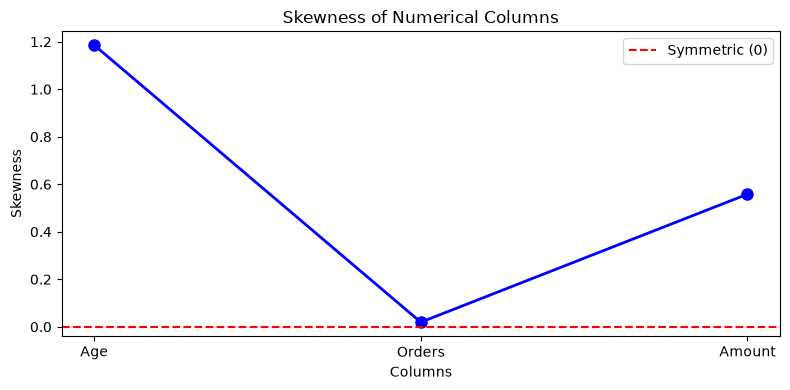

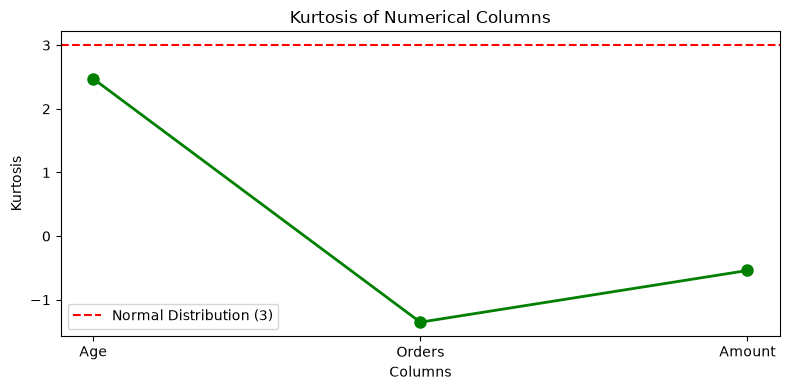

In [12]:
columns = ['Age', 'Orders', 'Amount']
skewness_values = [df[col].skew() for col in columns]
kurtosis_values = [df[col].kurtosis() for col in columns]

# Skewness Line Chart
plt.figure(figsize=(8, 4))
plt.plot(columns, skewness_values, marker='o', color='blue', linewidth=2, markersize=8)
plt.axhline(y=0, color='red', linestyle='--', label='Symmetric (0)')
plt.xlabel('Columns')
plt.ylabel('Skewness')
plt.title('Skewness of Numerical Columns')
plt.legend()
plt.tight_layout()
plt.show()

# Kurtosis Line Chart
plt.figure(figsize=(8, 4))
plt.plot(columns, kurtosis_values, marker='o', color='green', linewidth=2, markersize=8)
plt.axhline(y=3, color='red', linestyle='--', label='Normal Distribution (3)')
plt.xlabel('Columns')
plt.ylabel('Kurtosis')
plt.title('Kurtosis of Numerical Columns')
plt.legend()
plt.tight_layout()
plt.show()

### 2. Calculate the pairwise correlations (e.g., between Age and Amount, Orders and Amount)

In [13]:
print("Correlation between Age and Amount: ",df["Age"].corr(df["Amount"]))
print("Correlation between Orders and Amount: ",df["Orders"].corr(df["Amount"]))
print("Correlation between Orders and Age: ",df["Orders"].corr(df["Age"]))

Correlation between Age and Amount:  0.030941321745294504
Correlation between Orders and Amount:  -0.013183482461321921
Correlation between Orders and Age:  0.008089851507349427


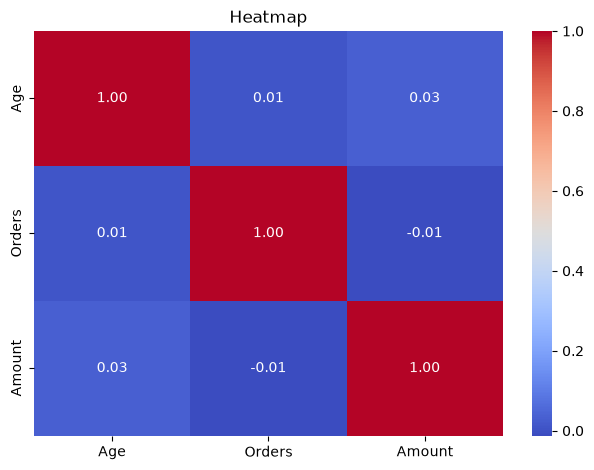

In [14]:
sns.heatmap(df[['Age','Orders','Amount']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Heatmap")
plt.tight_layout() 
plt.show()

# Data Exploration

### 1. Visualize insights:
- Top 5 states by total Amount

State
Uttar Pradesh     19374968.00
Maharashtra       14427543.00
Karnataka         13523540.00
Delhi             11603819.45
Madhya Pradesh     8101142.00
Name: Amount, dtype: float64


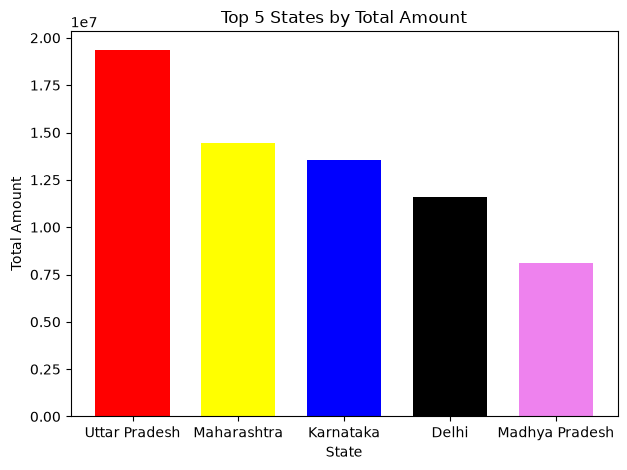

In [15]:
# combine all rows per state
top_states = df.groupby('State')['Amount'].sum()
# rank the states in descending order
top_states = top_states.sort_values(ascending=False).head(5)
print(top_states)
colors = ['red','yellow','blue','black','violet']
# display them using a bar graph
plt.bar(top_states.index, top_states.values, color=colors, width=0.7)
plt.xlabel('State')
plt.ylabel('Total Amount')
plt.title('Top 5 States by Total Amount')
plt.tight_layout()
plt.show()

- Distribution of Gender across Product_Category

Gender                    F    M
Product_Category                
Auto                     64   33
Beauty                  325   97
Books                    39   64
Clothing & Apparel     1854  801
Decor                    79   17
Electronics & Gadgets  1476  611
Food                   1771  719
Footwear & Shoes        782  277
Furniture               219  133
Games & Toys            273  113
Hand & Power Tools        9   17
Household items         284  236
Office                   75   38
Pet Care                144   68
Sports Products         264   92
Stationery               59   53
Tupperware               52   20
Veterinary               63   18


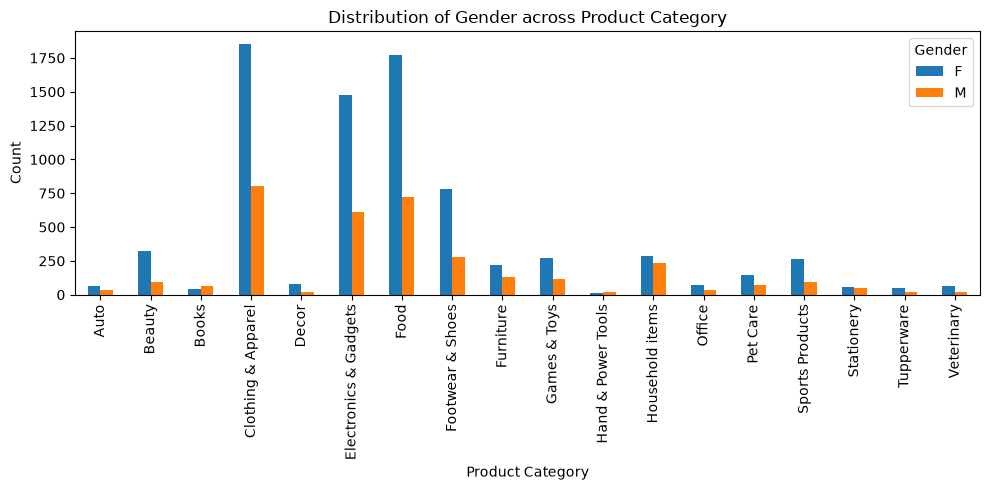

In [16]:
gender_product = df.groupby(['Product_Category', 'Gender']).size().unstack(fill_value=0)
print(gender_product)
gender_product.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.title('Distribution of Gender across Product Category')
plt.tight_layout()
plt.show()

- Age Group vs Average Amount

Age Group
Teen           9120.449324
Young Adult    9175.482704
Adult          9489.806482
Senior         9557.346604
Middle-Aged    9635.587976
Name: Amount, dtype: float64


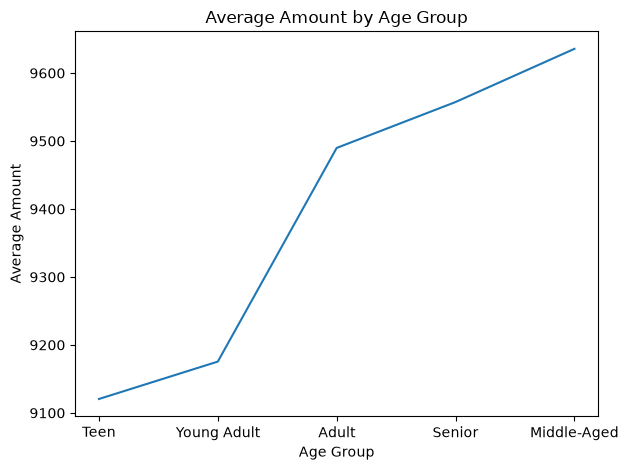

In [17]:
age_amount = df.groupby('Age Group')['Amount'].mean().sort_values()
print(age_amount)
plt.plot(age_amount)
plt.xlabel('Age Group')
plt.ylabel('Average Amount')
plt.title('Average Amount by Age Group')
plt.tight_layout()
plt.show()

- Marital_Status impact on orders

Marital_Status
0    16249
1    11732
Name: Orders, dtype: int64


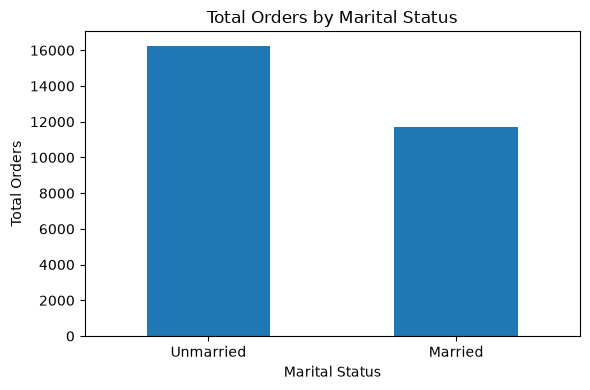

In [18]:
marital_orders = df.groupby('Marital_Status')['Orders'].sum()
print(marital_orders)
marital_orders.plot(kind='bar', figsize=(6, 4))
plt.xlabel('Marital Status')
plt.ylabel('Total Orders')
plt.title('Total Orders by Marital Status')
plt.xticks([0, 1], ['Unmarried', 'Married'], rotation=0)  # replace 0 and 1 with labels
plt.tight_layout()
plt.show()

### 2. Categorized analysis: Rank product_Category by average Amount, grouped by Zone. Visualize with a grouped bar chart.

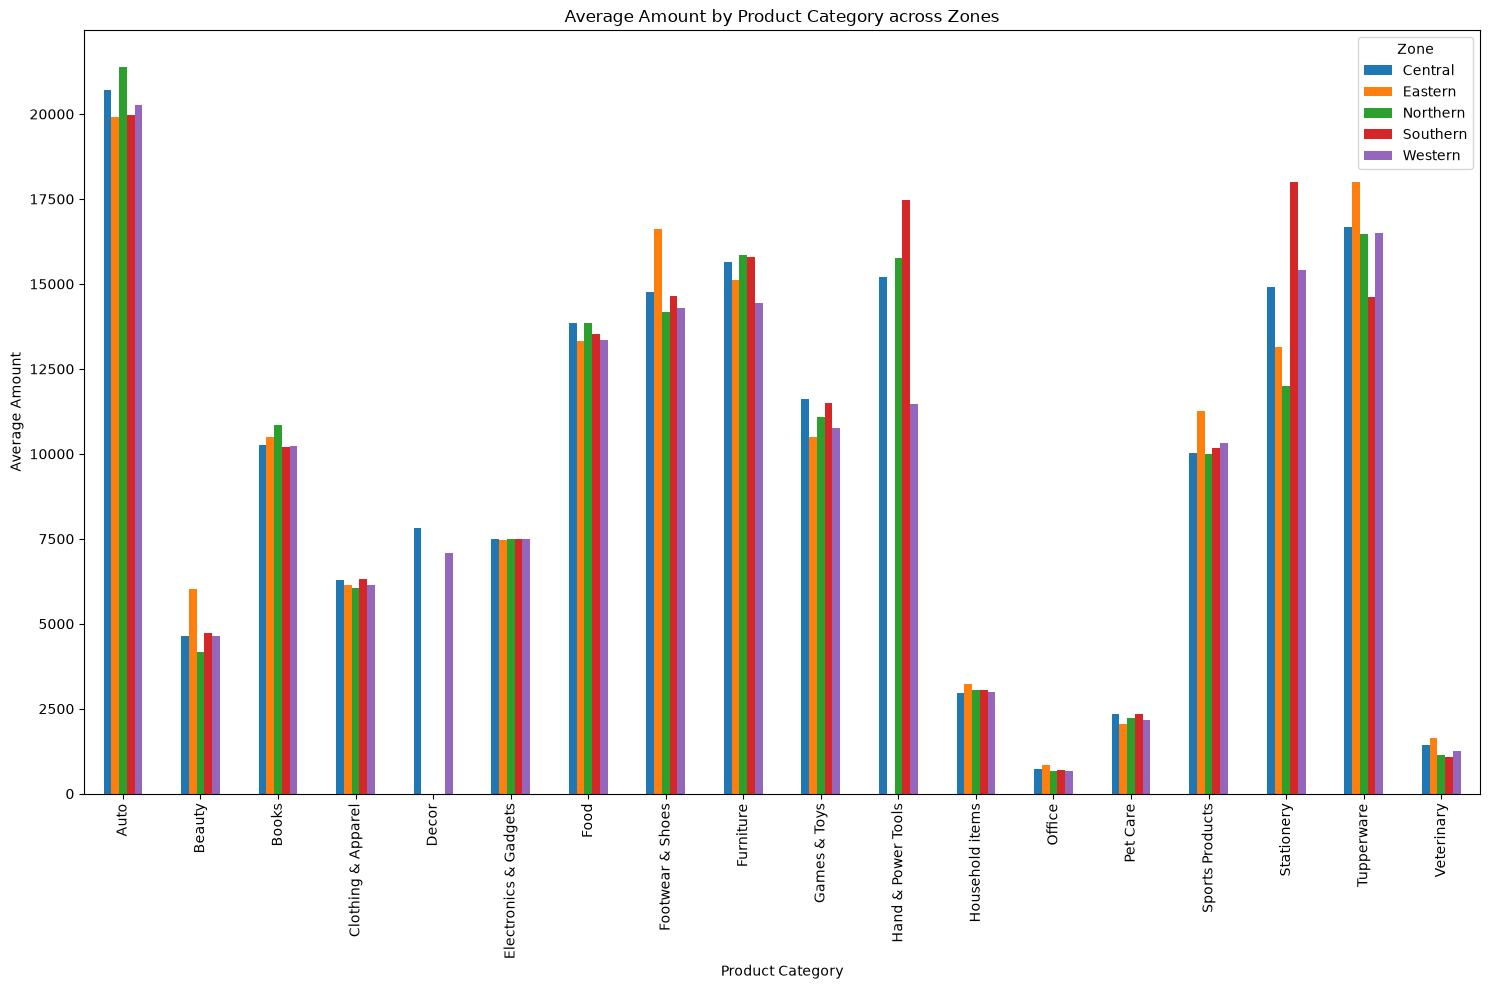

In [19]:
avg_amount = df.groupby(['Zone', 'Product_Category'])['Amount'].mean().reset_index() 
avg_amount['Rank'] = avg_amount.groupby('Zone')['Amount'].rank(ascending=False, method='dense') 
pivot_df = avg_amount.pivot(index='Product_Category',columns='Zone',values='Amount')
pivot_df.plot(kind='bar', figsize=(15, 10))
plt.xlabel('Product Category')
plt.ylabel('Average Amount')
plt.title('Average Amount by Product Category across Zones')
plt.tight_layout()
plt.show()

# Statistical Testing

### Test 1: Is there a difference in average Amount across Occupation groups?
- H0: Mean Amount is equal across occupations.
- HA: Mean Amount differs significantly.
- Test: Anova: Report p-value and conclusion.

In [20]:
groups = [
    group['Amount'].values 
    for name, group in df.groupby('Occupation')
]
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Mean Amount differs significantly across occupations.")
else:
    print("Fail to reject H0: No significant difference in mean Amount.")

F-statistic: 2.4770692386821302
p-value: 0.0016591465296956088
Reject H0: Mean Amount differs significantly across occupations.


### Test 2: Are Product_Category and Zone independent?
- H0: No Association between category and zone.
- HA: Association exists.
- Test: Chi-square test. Report p-value and conclusion

In [21]:
cont_table = pd.crosstab(df['Product_Category'], df['Zone'])
chi2, p_value, dof, expected = chi2_contingency(cont_table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a significant association between Product_Category and Zone.")
else:
    print("Fail to reject H0: No significant association (they are independent).")

Chi-square statistic: 1634.9668637157445
p-value: 1.4536117678958916e-296
Reject H0: There is a significant association between Product_Category and Zone.
